# PyG fundamentals: preserve the graph computation

Three live TODOs. The one-seed default runs the full training schedule; RUN_FULL=True executes all100 seeds. Author results in the prose are separate from your kernel.

## Runtime

Use the exact environment commands in [the reproduction guide](https://avistian.github.io/relational/labs/l086-reproduction.md). NeighborLoader requires pyg-lib or torch-sparse compiled for your installed torch. Do not silently replace the real loader with a mock.

In [ ]:
import torch, torch_geometric
import torch_geometric.typing as pyg_typing
print('torch',torch.__version__,'PyG',torch_geometric.__version__)
assert pyg_typing.WITH_PYG_LIB or pyg_typing.WITH_TORCH_SPARSE, 'Install the compiled sampling backend; see reproduction guide'
torch.set_num_threads(1)

## Retrieval before reading · 3 minutes

Close lesson 82. Write the shape of X, edge_index and W for a four-node graph with three features and two output channels. Which row of an edge list names the sender? Which labels may contribute gradients in transductive training? Why must degrees include self-loops?

<details><summary>Check after committing your answer</summary><p>X: [4,3]; edge_index: [2,E]; W: [3,2]. With source_to_target, row 0 is the sender, row 1 the receiver. Training labels supervise the objective; validation labels select the checkpoint. Add loops before measuring augmented degrees.</p></details>

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 086</p><p><strong>Build on what you know.</strong> <a href="https://avistian.github.io/relational/lessons/0082-gcn.html">Lesson 82</a> derived the GCN coefficients and <a href="https://avistian.github.io/relational/lessons/0083-graphsage.html">Lesson 83</a> separated roots from support. PyG changes the implementation tools; it should not silently change either mathematical operator or supervision boundary.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0087-link-prediction.html">Lesson 87</a> changes the target from nodes to pairs. <a href="https://avistian.github.io/relational/lessons/0088-graph-classification.html">Lesson 88</a> changes it to whole graphs. The same containers support these tasks, but their split units and readouts differ.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## Translate the operator into a tensor program

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">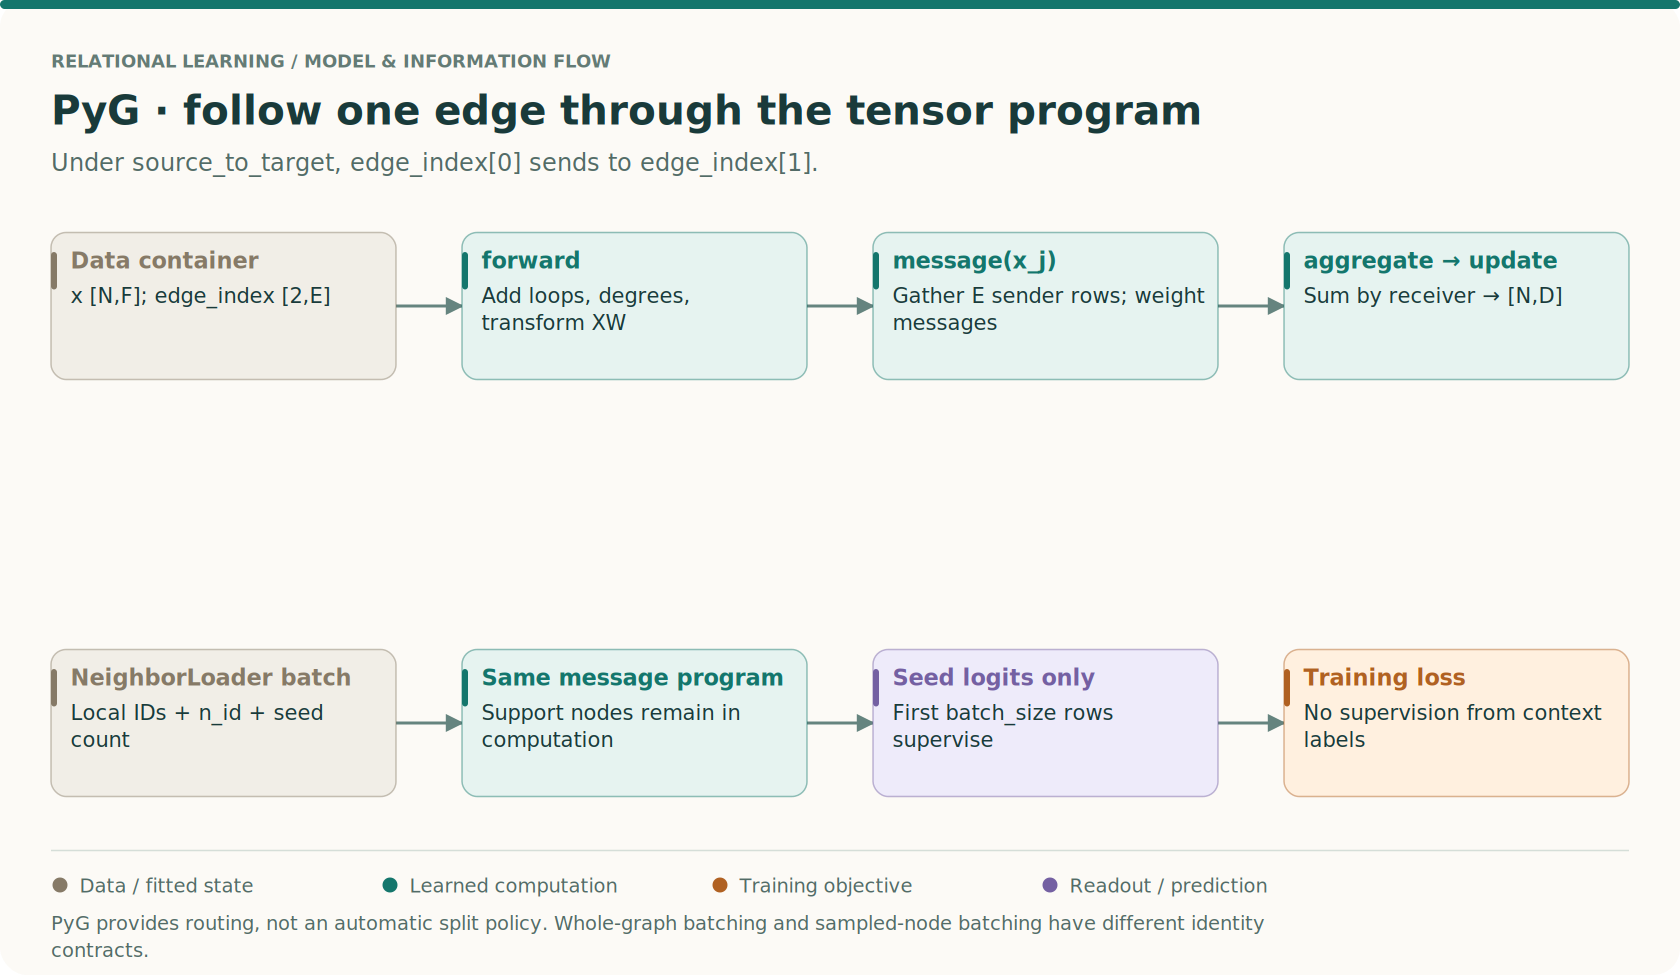</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read the abstraction and verify the index convention

Read [Fey & Lenssen's PyG paper](https://arxiv.org/html/1903.02428v3) and the [MessagePassing API](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html). For the installed version, inspect the configured flow direction. This lesson uses source_to_target: j is the sender and i the receiver. Tensor suffixes encode these roles, not arbitrary variable names.

### Route a tiny graph by hand

1. **Write the edges explicitly.** Let edge_index=[[0,2],[1,1]]. There are two directed edges, 0→1 and 2→1. The tensor has two rows because every edge has two endpoints, not because the graph has two nodes.
2. **Lift sender values.** With scalar x=[2,4,8], gathering x_j yields [2,8], one value per edge. Gathering x_i instead yields [4,4]; both arrays have length two but describe different programs.
3. **Reduce by destination.** Summing messages gives node outputs [0,10,0]. A mean gives [0,5,0] under the declared empty-neighborhood convention. GCN additionally includes loops and degree coefficients before this sum; the routing primitive alone is not the complete model.
4. **Retain isolated nodes.** Explicitly declare N=3, or another known node count when features are absent. Inferring nodes only from edge maxima can lose trailing isolated nodes, changing output alignment.
5. **Track local and global IDs in sampled batches.** If n_id=[7,42,99], local edge 2→0 is global edge 99→7. Keep local IDs for the batch tensor operations and use n_id when joining predictions back to the original dataset.
6. **Choose the supervised rows.** NeighborLoader places seeds first in this contract. Compute messages using the support, but apply the target loss to the first batch_size rows. For whole-graph batching, use the graph-membership vector and a graph readout instead; these are different meanings of a batch.

<details><summary>Check: two graphs each have node 0—should their features be merged?</summary><p>No. Disjoint-union batching offsets edge endpoints and records graph membership. The two local node zeros are separate entities. Heterogeneous graphs additionally give IDs a node type, so author 0 and paper 0 remain distinct even inside one database graph.</p></details>

**Your intermediate artifact:** annotate the source, destination, lifted messages, reduced tensor and original IDs for this example. Then compare the complete PyG layer's output and gradients with the explicit support-matrix implementation from Lesson 82.

<!-- depth-walkthrough:end -->



## One win: change the implementation without changing the operator

In [lesson 85](https://avistian.github.io/relational/lessons/0085-over-smoothing.html), deeper propagation could erase distinctions. Before testing a remedy, we need confidence that a library port still computes our intended graph operator. Your deliverable is a PyG GCN that matches lesson 82's outputs **and gradients**, plus an audited sampled batch. Allow 25 minutes for the core; run the complete benchmark separately.

PyG supplies graph containers and routing machinery. You still choose normalization, messages, supervision and evaluation. This is the tooling foundation for relational graphs: table-specific node IDs and labeled seed entities will soon replace the single Cora node space. [Fey & Lenssen, primary paper](https://arxiv.org/abs/1903.02428).



## Data: the graph is a set of aligned tensors

`Data(x=x, edge_index=e, y=y, num_nodes=N)` groups tensors; it does not enforce your split policy. Features have shape [N,F], labels [N], and integer edges [2,E]. Under `source_to_target`, edge column [j,i] sends j's message to i. An undirected edge needs both directions. Set num_nodes explicitly when features are absent so isolated nodes survive inference of graph size. [Data API](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Data.html).

```python
x = torch.tensor([[2.], [4.], [8.], [10.]])
edge_index = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]])
data = Data(x=x, edge_index=edge_index, num_nodes=4)
```

A—B—C is a path; D is isolated. `data.validate()` checks index consistency, not whether you accidentally included future edges. The lab checks directed routing separately because reversing every edge of an undirected graph can conceal an orientation bug.



## Trace the GCN through MessagePassing

For the unweighted undirected graph, add one self-loop per node and calculate d = [2,3,2,1]. Each j→i message is `(XW)[j] / sqrt(d[j]*d[i])`. The receiver sums incoming messages. With W=1, B receives 2/√6 + 4/3 + 8/√6 = 5.415816. D receives its own transformed feature only.

Predict B for C=20: the answer is 10.314796. The lesson page supplies an interactive control.

Predict what changes if C becomes 20. Then move the control. The degrees and weights remain fixed; only one message changes. The ordinary mean is shown as a separate operator.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">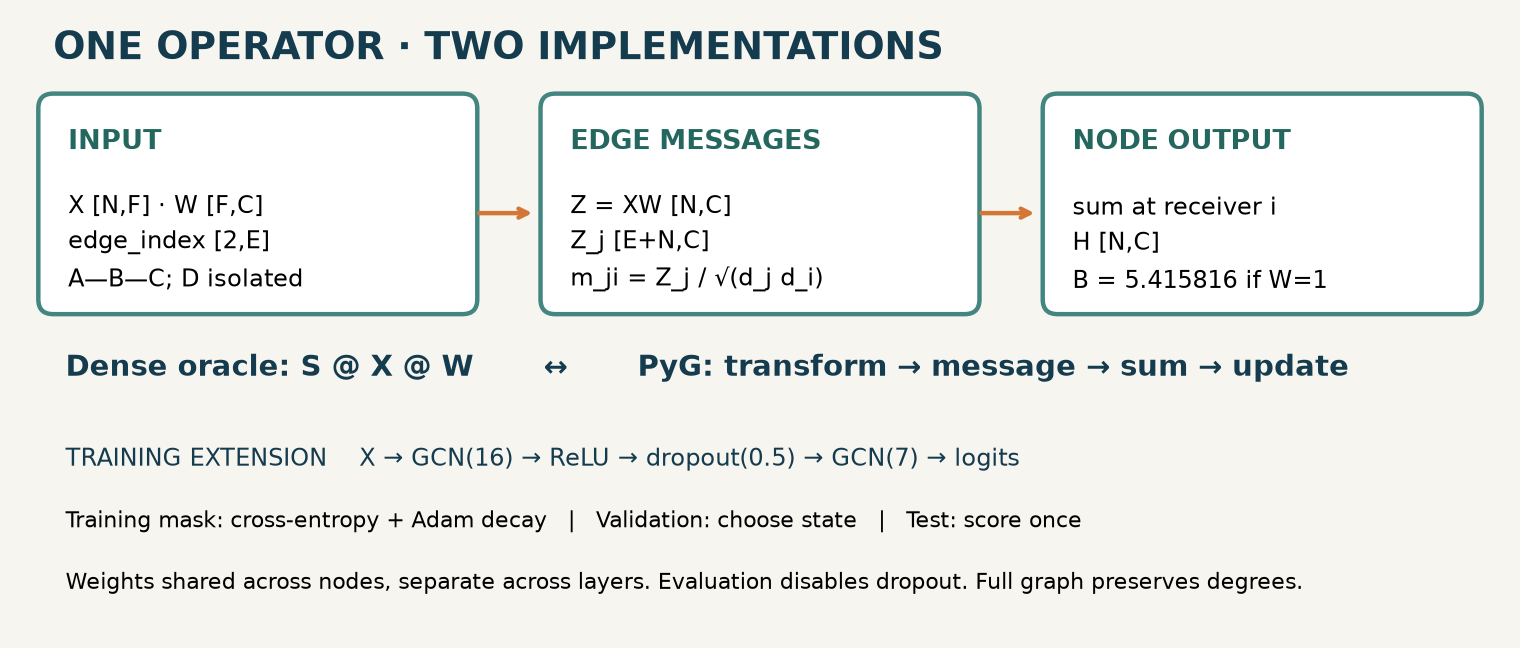</div><figcaption>GCN computation trace and the distinct historical PyG training extension; shape C denotes output channels.</figcaption></figure>

`forward` transforms features and computes edge coefficients. `propagate` orchestrates the following methods: `message` lifts source features into one row per edge; `aggregate` sums by destination; `update` receives the reduced node tensor. The default update is identity; our optional bias is added there. `x_j` means sender features, not a second independent input. [MessagePassing API](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html).

```python
class TraceGCN(MessagePassing):
    # Constructor creates W and calls super().__init__(aggr='add').
    def forward(self, x, edge_index):
        edges, norm = normalized_edges(edge_index, len(x), x.dtype)
        return self.propagate(edges, x=x @ self.weight, norm=norm)
    def message(self, x_j, norm):
        return norm[:, None] * x_j
```

The notebook contains the entire class and normalization, not an opaque import. Use bias=False for lesson 82 operator parity. Copy the same W into both implementations and disable dropout. Similar accuracy alone cannot certify identical computations. Compare the gradients of a shared scalar objective with respect to both X and W.



## Two meanings of “batch”

`Batch.from_data_list([g1,g2])` makes a disjoint union: concatenate node features, offset the second graph's edge IDs, and retain a `batch` vector mapping each node to its graph. There are no cross-graph messages. This prepares graph classification in lesson 88. [Batch API](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Batch.html).

`NeighborLoader` instead samples a computation graph around seeds from one larger graph. A two-layer model normally needs two sampling hops. With fanouts [10,5], a loose tree-shaped bound per seed is 1+10+50 nodes; shared neighbors reduce it. The hop list describes outward sampling from seeds, not a list of hidden layer widths.

```python
loader = NeighborLoader(data, input_nodes=train_mask,
                        num_neighbors=[10, 5], batch_size=64)
for batch in loader:
    logits = model(batch)
    loss = F.cross_entropy(logits[:batch.batch_size],
                           batch.y[:batch.batch_size])
```

The first `batch_size` nodes are seeds. The rest supply context. `batch.n_id` maps local node IDs back to the original graph; recover original edges with `batch.n_id[batch.edge_index]`. A batch seeded at global node 1 may place it at local node 0. Never use local IDs to index the original label array. Sampling requires a compatible compiled backend such as pyg-lib. The reproduction guide records the tested build. [NeighborLoader source and contract](https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/loader/neighbor_loader.html).

**Prediction:** if you flip labels of context nodes but keep seeds unchanged, should seed loss or its gradients change? The lab proves they do not. Context features can still affect seed predictions. This is expected in a transductive setting; availability of future relational features must be audited separately.

**GCN sampling trap:** recomputing degrees on a sampled subgraph changes normalization. Even all-neighbor sampling for a fixed number of hops does not necessarily preserve boundary-node degrees. The lesson's exact GCN parity and benchmark therefore use the full graph. The loader lab tests identity and supervision contracts; it does not claim sampled/full GCN equality. For exact evaluation, preserve full-graph coefficients and all required message paths, or use the full graph.



## HeteroData: IDs have a type

```python
h = HeteroData()
h['author'].x = torch.ones(2, 3)
h['paper'].x = torch.ones(3, 4)
h['author', 'writes', 'paper'].edge_index = torch.tensor([[0,1],[1,2]])
```

Author 0 and paper 0 are different entities. The relation key is (source type, relation, destination type); each edge row indexes its own node store. A reverse relation must be created explicitly when messages should flow backward. Different feature widths also require type-specific projections. Full heterogeneous modeling follows in lesson 98. [HeteroData API](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.HeteroData.html).



## Full reproduction: name the protocol before running

The named extension is **Fey & Lenssen, Table 1, GCN on fixed-split Cora: 81.5 ± 0.6% over 100 runs**. The complete graph contains 2,708 nodes and 1,433 features; label masks contain 140 training, 500 validation and 1,000 test nodes. Seeds here are 0–99. [Paper §3](https://arxiv.org/html/1903.02428v3).

We archive PyG release 1.2.0 at `d5aff37604c8e3247f5e807f2ba0ec6eeb4c661b`. It supplies an auditable implementation of the citation experiment, but its identity as the exact paper-run revision is unconfirmed. Crucially, this benchmark differs from the original Kipf TensorFlow release used in L082:

| Choice | L082 release port | Historical PyG citation benchmark |
|---|---|---|
| Bias | None | Both layers |
| Dropout | Sparse input and hidden | Hidden only, p=0.5 |
| Regularization | First weight matrix only | Adam weight decay on all parameters |
| Stopping | After initial 11 epochs | Only after epoch 100 |
| Selected state | Last weights | Lowest validation cross-entropy |

The PyG run uses hidden width 16, ReLU, Adam at 0.01 with weight decay 0.0005, and at most 200 epochs. After epoch 100 it stops if validation loss exceeds the preceding ten-loss mean. Test scoring occurs once after restoring the validation-selected state. The archived code scored test each epoch; deferring that read preserves its selection decision while making label isolation explicit. [Archived model](https://github.com/pyg-team/pytorch_geometric/blob/d5aff37604c8e3247f5e807f2ba0ec6eeb4c661b/benchmark/citation/gcn.py) · [Archived trainer](https://github.com/pyg-team/pytorch_geometric/blob/d5aff37604c8e3247f5e807f2ba0ec6eeb4c661b/benchmark/citation/train_eval.py).

**Fresh author execution:** 100 full-schedule runs; mean test accuracy **81.305%**, sample SD **0.714 percentage points**. These runs share one fixed graph and split; the SD measures initialization variation, not uncertainty across datasets. See [machine-readable results](https://avistian.github.io/relational/labs/_paper_l086_results.json).

This is a full-size modern reconstruction of one table cell, not the complete PyG paper. Original seeds and exact historical environment are unavailable; historical execution parity remains **INCOMPARABLE**. Runtime Table 4 on a GTX 1080 Ti, other datasets, and random-split experiments are **NOT_RUN**. A passing arithmetic test is implementation evidence, not paper-result reproduction.



## Lab: three live edits and an exit artifact

Open the student notebook. Implement `weighted_messages`, `seed_loss` and `global_edges`; each feeds an executed check or model. The solution includes complete visible code for the Cora loader, model and trainer. The short notebook run uses one full-schedule seed; set `RUN_FULL=True` to execute all 100. Do not confuse the displayed author results with a fresh run in your kernel.

Submit `l086-exit.json` with: output/gradient parity tolerances, the real sampler's n_id and remapped edges, proof that context labels do not supervise training, and your benchmark protocol/results. Explain why a sampled GCN can differ even when its MessagePassing class is correct. Re-answer that question tomorrow without opening the lesson.

Read the [paper](https://arxiv.org/abs/1903.02428), then the linked APIs. Keep the [compact reference](https://avistian.github.io/relational/reference/pyg-fundamentals.html) and [reproduction instructions](https://avistian.github.io/relational/labs/l086-reproduction.md). Ask the agent about any unclear tensor shape or failed check; bring the smallest failing graph. Lesson 87 adds a new split problem: hiding edges for link prediction.


## Attribution

Historical reference files are archived at sources/l086; adapted under MIT:

```text
Copyright (c) 2019 Matthias Fey <matthias.fey@tu-dortmund.de>

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.

```

In [ ]:
import copy

In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
import torch.nn.functional as F

In [ ]:
from torch_geometric.nn import MessagePassing

In [ ]:
from torch_geometric.data import Data, HeteroData, Batch

In [ ]:
from torch_geometric.loader import NeighborLoader

In [ ]:
from torch_geometric.utils import remove_self_loops, add_self_loops

### PROVIDED · normalized_edges

Replace self-loops, then compute symmetric endpoint-degree weights.

In [ ]:
def normalized_edges(edge_index, num_nodes, dtype):
    """Replace self-loops, then compute symmetric endpoint-degree weights."""
    edge_index, _ = remove_self_loops(edge_index)
    edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    src, dst = edge_index
    degree = torch.bincount(src, minlength=num_nodes).to(dtype)
    norm = degree[src].rsqrt() * degree[dst].rsqrt()
    return edge_index, norm

### TODO · weighted_messages

TODO 1: one scalar edge coefficient multiplies every message channel.

In [ ]:
def weighted_messages(x_j, norm):
    raise NotImplementedError("Complete weighted_messages")

In [ ]:
torch.testing.assert_close(weighted_messages(torch.tensor([[2.,4.],[3.,6.]]),torch.tensor([.5,2.])),torch.tensor([[1.,2.],[6.,12.]]))
print('CHECK: coefficient broadcasts across channels')

### PROVIDED · TraceGCN

Explicit transformation, source lifting, sum reduction and bias update.

In [ ]:
class TraceGCN(MessagePassing):
    """Explicit transformation, source lifting, sum reduction and bias update."""
    def __init__(self, inputs, outputs, bias=False):
        super().__init__(aggr='add', flow='source_to_target')
        self.weight = nn.Parameter(torch.empty(inputs, outputs))
        self.bias = nn.Parameter(torch.zeros(outputs)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, edge_index):
        edges, norm = normalized_edges(edge_index, x.size(0), x.dtype)
        return self.propagate(edges, x=x @ self.weight, norm=norm, size=(len(x),len(x)))

    def message(self, x_j, norm):
        return weighted_messages(x_j, norm)

    def update(self, aggr_out):
        return aggr_out if self.bias is None else aggr_out + self.bias

### TODO · seed_loss

TODO 2: NeighborLoader places supervised seeds before context nodes.

In [ ]:
def seed_loss(logits, batch):
    raise NotImplementedError("Complete seed_loss")

In [ ]:
b=Data(y=torch.tensor([1,0,1]));b.batch_size=1
z=torch.tensor([[1.,2.],[3.,4.],[5.,6.]],requires_grad=True)
l=seed_loss(z,b);l.backward();assert z.grad[1:].abs().sum()==0 and z.grad[0].abs().sum()>0
b.y[1:]=1-b.y[1:];torch.testing.assert_close(l,seed_loss(z,b))
print('CHECK: context labels are excluded')

### TODO · global_edges

TODO 3: both edge rows contain local IDs; recover original graph IDs.

In [ ]:
def global_edges(batch):
    raise NotImplementedError("Complete global_edges")

In [ ]:
b=Data(edge_index=torch.tensor([[0,2],[1,0]]));b.n_id=torch.tensor([7,3,9])
assert global_edges(b).tolist()==[[7,9],[3,7]]
print('CHECK: both endpoints remap')

### PROVIDED · toy_data

Inspect the computation.

In [ ]:
def toy_data():
    return Data(x=torch.tensor([[2.],[4.],[8.],[10.]]),
                edge_index=torch.tensor([[0,1,1,2],[1,0,2,1]]),
                y=torch.tensor([0,1,0,1]),num_nodes=4)

### PROVIDED · loader_check

Execute real sampling, including seed ordering, mapping and label isolation.

In [ ]:
def loader_check():
    """Execute real sampling, including seed ordering, mapping and label isolation."""
    data=toy_data()
    batch=next(iter(NeighborLoader(data,input_nodes=torch.tensor([1]),
        num_neighbors=[-1,-1],batch_size=1,shuffle=False)))
    assert batch.batch_size==1 and batch.n_id[0].item()==1
    assert set(batch.n_id.tolist())=={0,1,2}
    torch.testing.assert_close(batch.x,data.x[batch.n_id])
    original=set(map(tuple,data.edge_index.t().tolist()))
    assert all(tuple(e) in original for e in global_edges(batch).t().tolist())
    logits=torch.randn(batch.num_nodes,2,requires_grad=True)
    before=seed_loss(logits,batch);before.backward()
    assert logits.grad[1:].abs().sum()==0 and logits.grad[0].abs().sum()>0
    altered=batch.clone();altered.y[1:]=1-altered.y[1:]
    torch.testing.assert_close(before,seed_loss(logits,altered))
    return {'n_id':batch.n_id.tolist(),'local_edges':batch.edge_index.tolist(),
            'global_edges':global_edges(batch).tolist(),'seed_only_gradient':'PASS'}

### PROVIDED · CitationGCN

Historical PyG benchmark: biases, hidden dropout only, two 16-wide layers.

In [ ]:
class CitationGCN(nn.Module):
    """Historical PyG benchmark: biases, hidden dropout only, two 16-wide layers."""
    def __init__(self, features, classes):
        super().__init__()
        self.conv1=TraceGCN(features,16,bias=True)
        self.conv2=TraceGCN(16,classes,bias=True)
    def forward(self,data):
        h=F.relu(self.conv1(data.x,data.edge_index))
        h=F.dropout(h,p=.5,training=self.training)
        return self.conv2(h,data.edge_index)

### PROVIDED · as_data

Use the same hash-verified Cora data and row normalization as L082.

In [ ]:
def as_data(loaded):
    """Use the same hash-verified Cora data and row normalization as L082."""
    x,s,y,train,valid,test=loaded
    row,col=s.indices();keep=row!=col
    data=Data(x=x.to_dense(),edge_index=torch.stack([col[keep],row[keep]]),y=y,num_nodes=x.size(0))
    for key,idx in [('train_mask',train),('val_mask',valid),('test_mask',test)]:
        mask=torch.zeros(len(y),dtype=torch.bool);mask[idx]=True;data[key]=mask
    return data

### PROVIDED · train_citation

Full 200-epoch cap, stop after epoch 100, select smallest validation CE.
Unlike old code, test labels are read only once after checkpoint selection.

In [ ]:
def train_citation(data,seed):
    """Full 200-epoch cap, stop after epoch 100, select smallest validation CE.
    Unlike old code, test labels are read only once after checkpoint selection.
    """
    torch.manual_seed(seed)
    model=CitationGCN(data.num_features,int(data.y.max())+1)
    optimizer=torch.optim.Adam(model.parameters(),lr=.01,weight_decay=.0005)
    history=[];best=float('inf');chosen=None;best_epoch=None
    for epoch in range(1,201):
        model.train();optimizer.zero_grad()
        F.cross_entropy(model(data)[data.train_mask],data.y[data.train_mask]).backward()
        optimizer.step();model.eval()
        with torch.no_grad():vl=float(F.cross_entropy(model(data)[data.val_mask],data.y[data.val_mask]))
        history.append(vl)
        if vl<best:
            best=vl;chosen=copy.deepcopy(model.state_dict());best_epoch=epoch
        if epoch>100 and vl>torch.tensor(history[-11:-1]).mean().item():break
    model.load_state_dict(chosen);model.eval()
    with torch.no_grad():
        pred=model(data)[data.test_mask].argmax(1)
        accuracy=float((pred==data.y[data.test_mask]).float().mean())
    return {'seed':seed,'epochs':epoch,'selected_epoch':best_epoch,'validation_loss':history,'test_accuracy':accuracy}

## CHECK · independent dense operator and gradients

Predict D’s output before running. It must retain its own transformed feature.

In [ ]:
torch.manual_seed(86)
d=toy_data();c=TraceGCN(1,2).double();x=d.x.double().requires_grad_()
a=torch.zeros(4,4,dtype=torch.float64);a[d.edge_index[1],d.edge_index[0]]=1
t=a+torch.eye(4,dtype=torch.float64);q=t.sum(1).rsqrt();s=q[:,None]*t*q[None,:]
y=c(x,d.edge_index);expected=s@x@c.weight
torch.testing.assert_close(y,expected,atol=1e-12,rtol=1e-12)
g1=torch.autograd.grad(y.square().sum(),(x,c.weight),retain_graph=True)
g2=torch.autograd.grad(expected.square().sum(),(x,c.weight))
for a,b in zip(g1,g2):torch.testing.assert_close(a,b,atol=1e-12,rtol=1e-12)
print('CHECK: independent outputs and gradients')
sampling=loader_check();print(sampling)
b=Batch.from_data_list([d,d]);torch.testing.assert_close(c(b.x.double(),b.edge_index),y.repeat(2,1))
h=HeteroData();h['author'].x=torch.ones(2,3);h['paper'].x=torch.ones(3,4)
h['author','writes','paper'].edge_index=torch.tensor([[0,1],[1,2]])
assert h.validate(raise_on_error=True)

## PROVIDED · full Cora loader

Data manifest embedded; download only pinned bytes and verify SHA-256 before deserialization. No repository imports required.

In [ ]:
from pathlib import Path

In [ ]:
import hashlib

In [ ]:
import json

In [ ]:
import pickle

In [ ]:
import urllib.request

In [ ]:
import numpy as np

In [ ]:
import scipy.sparse as sp

In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
import torch.nn.functional as F

### PROVIDED · as_sparse

Inspect the computation.

In [ ]:
def as_sparse(a):
    a=sp.coo_matrix(a)
    return torch.sparse_coo_tensor(np.array([a.row,a.col]),a.data.astype('float32'),a.shape).coalesce()

### PROVIDED · normalized_support

Binary undirected loop-free adjacency -> sparse D^-1/2 (A+I) D^-1/2.
Add exactly one self-loop per node BEFORE computing degrees; retain isolated nodes.

In [ ]:
def normalized_support(a):
    """Binary undirected loop-free adjacency -> sparse D^-1/2 (A+I) D^-1/2.
    Add exactly one self-loop per node BEFORE computing degrees; retain isolated nodes.
    """
    a=sp.csr_matrix(a,dtype=float)
    if a.shape[0]!=a.shape[1] or (a-a.T).nnz or np.any(a.diagonal()):
        raise ValueError('Expected square undirected adjacency with no self-loops')
    if np.any(a.data!=1):raise ValueError('Expected binary adjacency')
    t=a+sp.eye(a.shape[0]);d=np.asarray(t.sum(1)).ravel()**-.5
    return as_sparse(sp.diags(d)@t@sp.diags(d))

### PROVIDED · load_cora

Verified pinned pickles only. Download missing files; reject changed bytes.

In [ ]:
def load_cora(root=None):
    """Verified pinned pickles only. Download missing files; reject changed bytes."""
    if root is None:
        root=Path.cwd()
        if (root/'labs').is_dir():root=root/'labs'
        if not (root/'_sources_l078.json').exists():
            root=Path(__file__).resolve().parents[1]
    root=Path(root);manifest=json.loads((root/'_sources_l078.json').read_text())
    for record in manifest['files']:
        if not record['path'].startswith('data/'):continue
        p=root/record['path'];p.parent.mkdir(parents=True,exist_ok=True)
        if not p.exists():
            url='https://raw.githubusercontent.com/tkipf/gcn/'+manifest['revision']+'/'+record['upstream']
            p.write_bytes(urllib.request.urlopen(url,timeout=60).read())
        if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:
            raise ValueError('Pinned data hash mismatch: '+str(p))
    folder=root/'data/l078'
    def read(name):
        with (folder/('ind.cora.'+name)).open('rb') as f:return pickle.load(f,encoding='latin1')
    x,y,tx,ty,allx,ally,graph=[read(k) for k in ['x','y','tx','ty','allx','ally','graph']]
    reorder=np.loadtxt(folder/'ind.cora.test.index',dtype=int);ordered=np.sort(reorder)
    features=sp.vstack((allx,tx)).tolil();features[reorder]=features[ordered]
    labels=np.vstack((ally,ty));labels[reorder]=labels[ordered]
    rows=[];cols=[]
    for i,neighbors in graph.items():
        for j in neighbors:rows.extend([i,j]);cols.extend([j,i])
    a=sp.coo_matrix((np.ones(len(rows)),(rows,cols)),shape=(len(labels),len(labels))).tocsr();a.data[:]=1
    s=normalized_support(a)
    mass=np.asarray(features.sum(1)).ravel();features=sp.diags(1/np.maximum(mass,1))@features
    return as_sparse(features),s,torch.tensor(labels.argmax(1)),torch.arange(len(y)),torch.arange(len(y),len(y)+500),torch.tensor(ordered)

In [ ]:
manifest={'revision': '39a4089fe72ad9f055ed6fdb9746abdcfebc4d81', 'repository': 'https://github.com/tkipf/gcn', 'files': [{'path': 'sources/l078/metrics.py', 'upstream': 'gcn/metrics.py', 'sha256': '953720296d440cfed948cd83c3162b72c4a5c759a5c1d1754254437cd0849f3f'}, {'path': 'sources/l078/utils.py', 'upstream': 'gcn/utils.py', 'sha256': '27bae983a6fdcaba352535e2a3edc46d1d9a0aabbcb7707c5212b41c27f9f8c4'}, {'path': 'sources/l078/models.py', 'upstream': 'gcn/models.py', 'sha256': 'd43548ab937264cf434e839dfd5768bd3e423579e48ae342608cafa4c8600c07'}, {'path': 'sources/l078/train.py', 'upstream': 'gcn/train.py', 'sha256': 'dab41c1c34315796ad998e1fcb4f8403719d059a970441ba358742a6bdd25136'}, {'path': 'sources/l078/LICENCE', 'upstream': 'LICENCE', 'sha256': 'f119df67ca11e39584fa0f5ee17cbfe8741b56b154d29fb21521e9ad01db57f8'}, {'path': 'sources/l078/layers.py', 'upstream': 'gcn/layers.py', 'sha256': 'c69ae03ae24aa6524eab61f2b2fec61c5938822fd225bdd4594406f1d24ec066'}, {'path': 'sources/l078/inits.py', 'upstream': 'gcn/inits.py', 'sha256': '21928770a797baf944392dee54eab83efaaa051a9d2365dee5d2f006689594a7'}, {'path': 'data/l078/ind.cora.ty', 'upstream': 'gcn/data/ind.cora.ty', 'sha256': '41f5ac76596a1699cc33f53084a2419e92961c42bb75f36fc38e616d348532ad'}, {'path': 'data/l078/ind.cora.ally', 'upstream': 'gcn/data/ind.cora.ally', 'sha256': '2b998f5cc7fedc86e7f97ca2498f47a1ffc1462c29e2d578b23bf3f62b6e7d71'}, {'path': 'data/l078/ind.cora.allx', 'upstream': 'gcn/data/ind.cora.allx', 'sha256': '9419ba2f26f5c35243db64aba110e0f35a04851609e0dc5433450676ca6b8543'}, {'path': 'data/l078/ind.cora.test.index', 'upstream': 'gcn/data/ind.cora.test.index', 'sha256': '297ce89af2b51a6a194181c7dbe1796c6a1cf9cd9349a88383b1b1e227867875'}, {'path': 'data/l078/ind.cora.x', 'upstream': 'gcn/data/ind.cora.x', 'sha256': '23cfa55d91c6f624233f5eb7b6e3f141f1bd2b2ae39608a63cf5d084bb27baab'}, {'path': 'data/l078/ind.cora.y', 'upstream': 'gcn/data/ind.cora.y', 'sha256': '94465c14eb53e04ca262198dcbb2521ee8af60fb3f3d546cd6ca24a511b0e7d1'}, {'path': 'data/l078/ind.cora.tx', 'upstream': 'gcn/data/ind.cora.tx', 'sha256': 'b9afbaa4a400df991f6f02ef677e1e44da55ffc04801fd02f9e673987829226a'}, {'path': 'data/l078/ind.cora.graph', 'upstream': 'gcn/data/ind.cora.graph', 'sha256': '58f13302f39dde8852dad6fe6d15b89b077b6d7f837626bce671ef80344b383d'}]}
root=Path.cwd()/'l086-cora-data';root.mkdir(exist_ok=True)
p=root/'_sources_l078.json'
if p.exists():assert json.loads(p.read_text())==manifest
else:p.write_text(json.dumps(manifest,indent=2))
loaded=load_cora(root);data=as_data(loaded)
assert data.x.shape==(2708,1433)
assert [int(data[k].sum()) for k in ['train_mask','val_mask','test_mask']]==[140,500,1000]
c=TraceGCN(1433,16)
with torch.no_grad():
 actual=c(data.x,data.edge_index)
 expected=torch.sparse.mm(loaded[1],torch.sparse.mm(loaded[0],c.weight))
 torch.testing.assert_close(actual,expected,atol=2e-6,rtol=2e-5)
print('CHECK: full Cora L082 operator parity')

In [ ]:
RUN_FULL=False
seeds=range(100) if RUN_FULL else range(1)
runs=[]
for seed in seeds:
 row=train_citation(data,seed);runs.append(row);print(seed,row['epochs'],row['test_accuracy'])
acc=np.array([r['test_accuracy'] for r in runs])
result={'status':'FULL_RECONSTRUCTION' if RUN_FULL else 'ONE_SEED_TEACHING_RUN','runs':runs,'mean':float(acc.mean()),'sample_sd':float(acc.std(ddof=1)) if len(acc)>1 else None,'sampling':sampling,'output_gradient_tolerance':1e-12,'historical_parity':'INCOMPARABLE'}
Path('l086-exit.json').write_text(json.dumps(result,indent=2))
print(result['status'],result['mean'])

## EXIT · explain the boundary

Add your explanation of sampled-degree mismatch to l086-exit.json. Change a context label and show unchanged seed loss; change a context feature and explain why logits can change. Tomorrow, reconstruct the ID mapping without looking.